# Antigenic Variation Analysis - Part 2: Look at overlap w/ GC events

# Import Statements (libraries + Functions)

In [1]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

%matplotlib inline

In [2]:
#import sklearn

In [3]:
import scipy.stats
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import spearmanr
from scipy.stats import ranksums

In [4]:
#from Bio import SeqIO

In [5]:
#import io

In [6]:
import json

In [7]:
# import screed
# import mmh3

In [8]:
#import subprocess

In [9]:
#from pycirclize import Circos

In [10]:
# from matplotlib.patches import Patch
# import matplotlib.patches as mpatches
# from matplotlib.lines import Line2D
# from matplotlib.patches import FancyArrowPatch
# import matplotlib.ticker as mticker


In [11]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

In [12]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [13]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

#### Define sets of coord cols for using BioFrame

In [14]:
Query_CoordCols = ("Query_Name", "Query_Start", "Query_End")
HmReg_CoordCols = ("Chr", "Start", "End")
HmRegion_CoordCols = HmReg_CoordCols
Epitope_CoordCols = ("Chrom", "Rv_Start", "Rv_End")
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")


#### Pandas Viewing Settings

In [15]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# ETE3 Settings & Parameters Setup

In [16]:

import ete3 as ETE

from ete3 import Tree

### Link to ETE3 documentation for tree layout style
 http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#interactive-visualization-of-trees

In [17]:
LinToColor_Dict = {"lineage1": "#DF83AC",
                   "lineage2": "#7098CB",
                   "lineage3": "#815D9F",
                   "lineage4": "#E76956",
                   "lineage5": "#B67548",
                   "lineage6": "#6AB79E",
                   "lineage8": "#E4515B", 
                   "Ancestral": "grey",
                   "None": "black",}


In [18]:


def Mtb_ColorBranchByLineage_Layout(node):
    F = ETE.TextFace(node.name, fsize=2)
    if node.is_leaf():
        #NameAnd_Lineage_Text =  f"  {node.name} {node.Mtb_lineage}"
        #F_NameAndLineage = ETE.TextFace(NameAnd_Lineage_Text, fsize=3)
        
        #ETE.add_face_to_node(F_NameAndLineage, node, column=0, position="branch-right")

        
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
        nstyle["fgcolor"] = "black"
        nstyle["size"] = 1
        
        Node_PrimaryLin = node_To_PrimaryLin_Dict.get(node.name, "None")
        
        nstyle["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
          
        node.set_style(nstyle)
        node.margin_left = 10        
    else: 
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
        nstyle["fgcolor"] = "black"
        nstyle["size"] = 0
        
        Node_PrimaryLin = node_To_PrimaryLin_Dict.get(node.name, "None")
        
        nstyle["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        
        node.set_style(nstyle)

ts_3 = ETE.TreeStyle()
ts_3.show_leaf_name = False
ts_3.show_branch_length = False
ts_3.show_branch_support = False
ts_3.show_scale = True #True
ts_3.branch_vertical_margin = 2
ts_3.layout_fn = Mtb_ColorBranchByLineage_Layout
ts_3.rotation = 90

ts_3_circ = ETE.TreeStyle()
ts_3_circ.mode = "c" # draw tree in circular mode
ts_3_circ.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_3_circ.arc_span = 180
ts_3_circ.show_leaf_name = False
ts_3_circ.show_branch_length = False
ts_3_circ.show_branch_support = False
ts_3_circ.show_scale = True #True
ts_3_circ.branch_vertical_margin = 2
ts_3_circ.layout_fn = Mtb_ColorBranchByLineage_Layout


ts_ColLin = ETE.TreeStyle()
ts_ColLin.show_leaf_name = False
ts_ColLin.show_branch_length = False
ts_ColLin.show_branch_support = False
ts_ColLin.show_scale = True #True
ts_ColLin.branch_vertical_margin = 2
ts_ColLin.layout_fn = Mtb_ColorBranchByLineage_Layout
ts_ColLin.rotation = 90

ts_ColLin_circ = ETE.TreeStyle()
ts_ColLin_circ.mode = "c" # draw tree in circular mode
ts_ColLin_circ.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_ColLin_circ.arc_span = 180
ts_ColLin_circ.show_leaf_name = False
ts_ColLin_circ.show_branch_length = False
ts_ColLin_circ.show_branch_support = False
ts_ColLin_circ.show_scale = True #True
ts_ColLin_circ.branch_vertical_margin = 2
ts_ColLin_circ.layout_fn = Mtb_ColorBranchByLineage_Layout



ts_4 = ETE.TreeStyle()
ts_4.show_leaf_name = False
ts_4.show_branch_length = False
ts_4.show_branch_support = False
ts_4.show_scale = True #True
ts_4.branch_vertical_margin = 2
#ts_4.layout_fn = Mtb_LabelNodeByNumEvents
ts_4.rotation = 90
      
ts_4_NoScale = ETE.TreeStyle()
ts_4_NoScale.show_leaf_name = False
ts_4_NoScale.show_branch_length = False
ts_4_NoScale.show_branch_support = False
ts_4_NoScale.show_scale = False #True
ts_4_NoScale.branch_vertical_margin = 2
#ts_4.layout_fn = Mtb_LabelNodeByNumEvents
ts_4_NoScale.rotation = 90
      
ts_4_circ = ETE.TreeStyle()
ts_4_circ.mode = "c" # draw tree in circular mode
ts_4_circ.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_4_circ.arc_span = 180
ts_4_circ.show_leaf_name = False
ts_4_circ.show_branch_length = False
ts_4_circ.show_branch_support = False
ts_4_circ.show_scale = False #True
ts_4_circ.branch_vertical_margin = 2
#ts_4_circ.layout_fn = Mtb_LabelNodeByNumEvents
ts_4_circ.rotation = 0 #90


ts_4_FullCirc = ETE.TreeStyle()
ts_4_FullCirc.mode = "c" # draw tree in circular mode
ts_4_FullCirc.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_4_FullCirc.arc_span = 360
ts_4_FullCirc.show_leaf_name = False
ts_4_FullCirc.show_branch_length = False
ts_4_FullCirc.show_branch_support = False
ts_4_FullCirc.show_scale = False #True
ts_4_FullCirc.branch_vertical_margin = 2
#ts_4_FullCirc.layout_fn = Mtb_LabelNodeByNumEvents
#ts_4_FullCirc.rotation = 0 #90




# Setup ETE3 and related viz function

In [19]:
import ete3 as ETE

from ete3 import Tree

# https://github.com/ipython/ipython/issues/10627
import os
os.environ['QT_QPA_PLATFORM']='offscreen'

#### Setup ETE3 plotting functions and styles
[Link to ETE3 documentation for tree layout style](http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#interactive-visualization-of-trees)

### Define function(s) for visualizing # of events & highlighting specific phylogeny branches

In [20]:
def labelNodesByNumEvents_V6(nodeToNumEventsDict, input_Tree):

    input_Tree_Labeled = input_Tree.copy()
 
    for n in input_Tree_Labeled.traverse():
        
        Node_NumEvents = nodeToNumEventsDict.get(n.name, 0)

        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
        nstyle["size"] = 0 + (1 * Node_NumEvents)/2

        if Node_NumEvents > 0:
            nstyle["fgcolor"] = "purple"
        if Node_NumEvents == 0:
            nstyle["fgcolor"] = "black"   
        
        n.set_style(nstyle)

        if Node_NumEvents > 0:
            n.img_style["hz_line_color"] = "purple"
         
    return input_Tree_Labeled


### Dev Code to quantify number of GCE per branch in the phylogeny

In [21]:
def highlight_TargetNodes_V3_WiLineageBlocks(targetNodes, input_Tree):

    input_Tree_Labeled = input_Tree.copy()
        
    # Draws nodes as small red spheres of diameter equal to 10 pixels
    i_nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
    #i_nstyle["shape"] = "sphere"
    i_nstyle["size"] = 0.3
    i_nstyle["fgcolor"] = "purple" #hex_color #"red"
    i_nstyle["vt_line_color"] = "purple"
    i_nstyle["hz_line_color"] = "purple"
    i_nstyle["hz_line_width"] = 1

    for n in input_Tree_Labeled.traverse():

        Node_PrimaryLin = node_To_PrimaryLin_Dict.get(n.name, "None")
        Node_LinColor = LinToColor_Dict.get(Node_PrimaryLin, "black")

        
        # Add a colored block to the left of the leaf
        if n.is_leaf():
            block = faces.RectFace(width=3, height=3, fgcolor=None, bgcolor=Node_LinColor)
            n.add_face(block, column=-1, position='aligned' )#position="aligned")  # Align to the left

        
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style

        nstyle["size"] = 0
        nstyle["fgcolor"] = "black"

        nstyle["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["vt_line_color"] = "black"
        nstyle["hz_line_color"] = "black"
        nstyle["vt_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
        nstyle["hz_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
        #nstyle["hz_line_width"] = 1
        #nstyle["vt_line_width"] = 1
        
        if n.is_leaf():
            nstyle["size"] = 1
        
        if n.name in targetNodes:
            nstyle["size"] = 2
            #nstyle["fgcolor"] = "red" #hex_color #"red"
            #nstyle["vt_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
            nstyle["vt_line_color"] = "purple"
            nstyle["hz_line_color"] = "purple"
            nstyle["hz_line_width"] = 2
            nstyle["shape"] = "circle"
            nstyle["size"] = 2
            
            nstyle["fgcolor"] = "purple" #"darkred"

        n.set_style(nstyle)

    return input_Tree_Labeled

### Dev Code to highlight specific branch(es) of the phylogeny

In [22]:

def highlight_TargetNodes_V2(targetNodes, input_Tree, verbose = False):

    input_Tree_Labeled = input_Tree.copy()
        
    # Draws nodes as small red spheres of diameter equal to 10 pixels
    i_nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style

    for n in input_Tree_Labeled.traverse():

        Node_PrimaryLin = node_To_PrimaryLin_Dict.get(n.name, "None")
        
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style

        nstyle["size"] = 0
        nstyle["fgcolor"] = "black"

        nstyle["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["vt_line_color"] = "black"
        nstyle["hz_line_color"] = "black"
        nstyle["vt_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
        nstyle["hz_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
            
        if n.is_leaf():
            nstyle["size"] = 0
        
        if n.name in targetNodes:
            
            if verbose: print(n.name, "found. We will style this node differently.")
                
            #nstyle["fgcolor"] = "red" #hex_color #"red"

            nstyle["shape"] = "sphere"
            nstyle["size"] = 3
            nstyle["fgcolor"] = "darkred" #"darkred"
            nstyle["vt_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
            nstyle["vt_line_color"] = "darkred"
            nstyle["hz_line_color"] = "darkred"
            nstyle["hz_line_width"] = 1
            n.set_style(nstyle)

        else:
            n.set_style(nstyle)
            n.img_style["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
            n.img_style["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")

        n.set_style(nstyle)

    return input_Tree_Labeled




# Parse `Mtb151CI` Isolate Metadata

In [23]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [24]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [25]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  
ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


# Import/parse processed H37rv genome annotations

In [26]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [27]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded


### Parse the WHO AR Variant Catalog (Mtb)

In [28]:
WHO_ResVar_DF = pd.read_csv("../../References/WHO_MtbAMR_Catalog/WHO_resistance_variants_all.csv", sep =",")
WHO_ResVar_LVL1_DF = WHO_ResVar_DF[ WHO_ResVar_DF["confidence"] == '1) Assoc w R']
WHO_ResVar_DF.shape

(17419, 5)

In [29]:
WHO_ResVar_LVL1_DF.shape

(201, 5)

In [30]:
WHO_ConfResGenes = list(WHO_ResVar_LVL1_DF["gene"].unique())
print(len(WHO_ConfResGenes))
print( WHO_ConfResGenes )

15
['inhA', 'rrs', 'eis', 'tlyA', 'embB', 'embA', 'ethA', 'katG', 'gyrA', 'rplC', 'gyrB', 'pncA', 'rpoB', 'rpsL', 'gid']


# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [31]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"


### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [32]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                    sep="\t")
#HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"] = HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 13)

In [33]:
Rv_HHR_DF = HmMapRegs_ParaRegs_k19w19_DF
Rv_HHR_DF.shape

(200, 13)

In [34]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                        sep="\t")

#HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"] = HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [35]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 13)

In [36]:
HmMapRegs_ParaRegs_k19w19_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001


#### Peak at head of each HmMap Regions DFs

In [37]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004


In [38]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [39]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 24)

In [40]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 34)

In [41]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 34)

In [42]:
HmMap_Aln_PR_ExactCopy_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID == 1.0")
print(HmMap_Aln_PR_ExactCopy_DF.shape)

(255, 34)


In [43]:
HmMap_Aln_PR_NoPerfAln_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID != 1.0")
print(HmMap_Aln_PR_NoPerfAln_DF.shape)

(385, 34)


In [44]:

HmMap_Aln_PR_MaxSeqID99_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID <= 0.99")
print(HmMap_Aln_PR_MaxSeqID99_DF.shape)

(331, 34)


### Parse in HomologyMap Alignment Variants DFs

In [45]:
Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

In [46]:
# Build trimmed + unique HM SNPs DF
UnqSNPs_TarCol = ['Query_Name', 'Query_Start', 'Query_End', 'Ref', 'Alt', 'SNP']

HM_Var_SNPs_TrimUnq_DF = Mtb_HM_Var_SNPs_DF[UnqSNPs_TarCol].drop_duplicates()
HM_Var_SNPs_TrimUnq_DF.shape

(51590, 6)

In [47]:
Mtb_HM_Var_DF.shape

(79508, 13)

In [48]:
Mtb_HM_Var_SNPs_DF.shape

(65617, 13)

# Parse curated TB antigens + epitopes (T-cell, CD4+)
Source Datasets: (Panda-24, Lindestam-16)

In [49]:
Repo_Epitope_MainDir = "../../Data/220813_MtbEpitopes"

#LPM_AllAssayedPeptides_Mapped_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.AllAssayed.V1.tsv" 

LPM_AllAssayedPeptides_WiMutInfo_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.All.AnnoByMutFreq.V2.tsv" 

Rv_Genes_Epitope_SummStats_TSV = f"{Repo_Epitope_MainDir}/240820.RvGene.EpitopeMappingStats.V1.tsv"


### Parse in DF of all epitope mapping results (all assayed peptides, N = )

In [50]:
LPM_AllPep_V2_DF = pd.read_csv(LPM_AllAssayedPeptides_WiMutInfo_TSV, sep = "\t")
LPM_AllPep_V2_DF.shape

(18741, 30)

### Subset DF for only POSITIVE EPITOPES or NEGATIVE PEPTIDES 

In [51]:
LPM_AllPep_V2_DF.shape

(18741, 30)

In [52]:
LPM_PosEpi_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == True")
LPM_PosEpi_V2_DF.shape

(424, 30)

In [53]:
LPM_PosEpi_InL2Antigen_V2_DF = LPM_PosEpi_V2_DF.query("Antigen_LVL2 == True")
LPM_PosEpi_InL2Antigen_V2_DF.shape

(342, 30)

In [54]:
LPM_NegPep_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == False")
LPM_NegPep_V2_DF.shape

(18317, 30)

## Parse gene-level epitope mapping summary for all H37Rv genes

In [55]:
Rv_Genes_EpitopeSummary_DF = pd.read_csv(Rv_Genes_Epitope_SummStats_TSV, sep="\t")
Rv_Genes_EpitopeSummary_DF.shape

(3841, 20)

In [56]:
Rv_Genes_EpitopeSummary_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb
0,NC_000962.3,0,1524,+,CDS,Rv0001,dnaA,information pathways,information pathways,0,8,8,0.0,762.0,1524,False,False,0,False,NonReactive-Unq
1,NC_000962.3,2051,3260,+,CDS,Rv0002,dnaN,information pathways,information pathways,0,6,6,0.0,2655.5,1209,False,False,0,False,NonReactive-Unq
2,NC_000962.3,3279,4437,+,CDS,Rv0003,recF,information pathways,information pathways,0,6,6,0.0,3858.0,1158,False,False,0,False,NonReactive-Unq
3,NC_000962.3,4433,4997,+,CDS,Rv0004,Rv0004,conserved hypotheticals,conserved hypotheticals,0,3,3,0.0,4715.0,564,False,False,0,False,NonReactive-Unq
4,NC_000962.3,5239,7267,+,CDS,Rv0005,gyrB,information pathways,information pathways,0,8,8,0.0,6253.0,2028,False,False,0,False,NonReactive-Unq


# Parse gene-level epitope + mutation + GCE stats - (antigen/epitope info, GCE info, Mutational Burden, etc)

In [57]:
Repo_AntigenMut_MainDir = "../../Data/250609.AntigenMutationalBurdenAnalysis"

Rv_Gene_MutStats_V1_TSV     = f"{Repo_AntigenMut_MainDir}/250808.RvGenes.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv"

Rv_Antigens_MutStats_V1_TSV = f"{Repo_AntigenMut_MainDir}/250808.RvL2Antigens.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv"

PerRvPosition_EpitopeCovStats_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvPos.EpitopeCoverage.AssayedPosOnly.V1.tsv.gz"

PerRvCodon_MutationFreq_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvCodon.MissenseMutatationFreq.V1.tsv.gz"

### a) Parse gene-level - mutational burden and epitope mapping summary DFs

In [58]:
Genes_GCandMutFreqStats_DF = pd.read_csv(Rv_Gene_MutStats_V1_TSV,
                                           sep = "\t")

Genes_GCandMutFreqStats_DF.shape

(3841, 36)

In [59]:
Antigen_GCandMutFreqStats_DF = pd.read_csv(Rv_Antigens_MutStats_V1_TSV,
                                           sep = "\t")

Antigen_GCandMutFreqStats_DF.shape

(53, 38)

In [60]:
Antigen_GCandMutFreqStats_DF["Length"].sum()

48474

In [61]:
Antigen_GCandMutFreqStats_DF["Length_WiPosEpitope"].sum()

9117

In [62]:
# Antigen_GCandMutFreqStats_DF = Genes_GCandMutFreqStats_DF.query("Antigen_LVL2 == True")
# Antigen_GCandMutFreqStats_DF.shape

### b) Parse Per Codon Position Mutation Freq (Across Gubbins ASR SNP Events) + Epitope mapping coverage DFs

In [63]:
RvPerCodon_NSMutFreq_DF = pd.read_csv(PerRvCodon_MutationFreq_TSV,
                                  sep = "\t")
RvPerCodon_NSMutFreq_DF.shape 

(12132, 4)

### c) Parse Per Genome Position  Epitope mapping coverage DF

In [64]:
Rv_EpitopeCov_NonZero_DF = pd.read_csv(PerRvPosition_EpitopeCovStats_TSV,
                                  sep = "\t")

Rv_EpitopeCov_NonZero_DF.shape

(746901, 5)

In [65]:
Rv_EpitopeCov_NonZero_DF.head(2)

,chrom,start,end,Cov_PosEpitopes,Cov_AssayedPeptides
0,NC_000962.3,537,538,0,1
1,NC_000962.3,538,539,0,1


# Parse `Mtb151CI` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [66]:
AnalysisName = "250901.WGA151CI.V9"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

WGA151_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = WGA151_Gubbins_V1_OutputDir

WGA151_Gubbins_OutPrefix = "Gubbins"

WGA151_Gubbins_FullPrefix_PATH  = f"{WGA151_Gubbins_V1_OutputDir}/{WGA151_Gubbins_OutPrefix}"

WGA151_Gubbins_FilePath_Dict = {}

WGA151_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{WGA151_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
WGA151_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{WGA151_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
WGA151_Gubbins_FilePath_Dict["BranchStats_CSV"]                 = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
WGA151_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]     = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"

WGA151_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]             = f"{WGA151_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]              = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
WGA151_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]       = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"

WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSandEpitope.All.V2.tsv"  


RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV = f"{Gubbins_V1_OutputDir}/Gubbins.All_GCEs.AnnoBy.EpitopeEffect.V3.tsv"

WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"] = RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV



######### Add Event to Paralog Mapping Results File Paths ##########

EventMapping_ResultsDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"

GRE_Anno_ByTopHomologMatch_TSV              = f"{EventMapping_ResultsDir}/GubbinsEvents.WiParalogMapping.V1.tsv"
EventMappingToAllParalogs_Info_TSV_PATH     = f"{EventMapping_ResultsDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"
Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{EventMapping_ResultsDir}/EventMapping.DictOf.KmerComparisons.pickle"   


WGA151_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"]       = GRE_Anno_ByTopHomologMatch_TSV
WGA151_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"]       = EventMappingToAllParalogs_Info_TSV_PATH
WGA151_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"]   = Pickle_PATH_dictOf_EventAndHomolog_KmerComp

HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"

WGA151_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"] = HmRegions_MappedEvents_TSV
WGA151_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"]       = HmPairs_MappedEvents_TSV

####################################################################


## Parse Gene Conv Event Info (pGCEs + mGCEs)

In [67]:
pGCE_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"],
                         sep = "\t")

pGCE_DF.shape

(324, 50)

In [68]:
pGCE_EventIDs = pGCE_DF["EventID"].unique()
len(pGCE_EventIDs)

324

#### Filter All putative GC events to MAPPED GC events

In [69]:
mGCE_DF = pGCE_DF.query("(Max_KmerMatch_ToHm > 0.5)")
mGCE_DF.shape

(213, 50)

In [70]:
mGCE_EventIDs = mGCE_DF["EventID"].unique()
len(mGCE_EventIDs)

213

In [71]:
pGCE_DF.head(1)

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
0,NC_000962.3,103600,104478,0.0,.,Node_148,Node_133,1737.432787,10,"['mada_2-31', 'mada_1-41', 'MT_0080', 'mada_10...",103599,104038.5,879,NaN,"Rv0093c,Rv0094c","Rv0093c,Rv0094c",False,False,True,False,Event_001,2,1,0,0,PR_HmRegion_002,0,0,1,1,130,False,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.8608,NaN,79,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,False,0,0,0,.


In [75]:
pGCE_DF.query("Max_KmerMatch_ToHm <= 0.5").shape

(82, 50)

## Parse Gubbins ASR SNP files (w/ Codon Variant Annotations)

In [77]:
Gub_SNPs_V2_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"],
                                         sep = "\t")

Gub_SNPs_V2_DF.shape

(26508, 23)

In [78]:
Gub_SNPs_V2_DF.head()

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
0,1088,Node_1,N1176,G,A,NaN,1087,NC_000962.3,0,0,Unq,1,dnaA,+,1087.0,363.0,2.0,S,N,1087,1088,lineage5,0
1,10321,Node_1,N1176,C,T,NaN,10320,NC_000962.3,0,0,Unq,1,Rv0007,+,407.0,136.0,3.0,NaN,NaN,10320,10321,lineage5,0
2,11846,Node_1,N1176,C,G,NaN,11845,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11845,11846,lineage5,0
3,16515,Node_1,N1176,T,C,NaN,16514,NC_000962.3,0,0,Unq,1,pknB,-,955.0,319.0,2.0,D,G,16514,16515,lineage5,0
4,34063,Node_1,N1176,C,T,NaN,34062,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34062,34063,lineage5,0


### Subset Gubbins ASR SNPs (V2 Table) into groups of interest

In [79]:
Gub_SNPs_NSMutOnly_DF       = Gub_SNPs_V2_DF[~Gub_SNPs_V2_DF["Mut_AA"].isna()].query("Ref_AA != Mut_AA")

Gub_SNPs_NSMutIn_pGCE_DF    = Gub_SNPs_NSMutOnly_DF.query("EventID != 'None'")

Gub_SNPs_NSMutIn_mGCE_DF    = Gub_SNPs_NSMutOnly_DF[ Gub_SNPs_NSMutOnly_DF["EventID"].isin(mGCE_EventIDs) ]

Gub_SNPs_NSMutInEpitope_DF  = Gub_SNPs_NSMutOnly_DF.query(" N_Epitopes_Overlap > 0 ")


In [80]:
Gub_SNPs_NSMutOnly_DF.shape

(13883, 23)

In [81]:
Gub_SNPs_NSMutIn_pGCE_DF.shape

(13883, 23)

In [82]:
Gub_SNPs_NSMutIn_mGCE_DF.shape

(994, 23)

In [83]:
Gub_SNPs_NSMutInEpitope_DF.shape

(175, 23)

# Begin Analysis

# Part 1: Analysis of GC events mutating MHC-II antigens & epitopes

## Basic questions to ask of GC events mutating epitopes/antigens

In [84]:
mGCE_DF.shape

(213, 50)

In [85]:
pGCE_DF.shape

(324, 50)

In [86]:
mGCE_DF.columns

Index(['seqname', 'start_1based', 'end_1based', 'score', 'strand', 'Parent_Node', 'Child_Node', 'neg_log_likelihood', 'snp_count', 'taxa_List', 'start_0based', 'CenterOfRegion', 'EventLen', 'Lineage', 'Overlap_Genes', 'Overlap_Gene_RvIDs', 'Contains_Esx', 'Contains_PEPPE', 'Contains_REP13E12', 'NoOverlap_Wi_PEPPE_Esx_13E12_Genes', 'EventID', 'N_HmMapAln_PR_Ovrlap', 'OvrlapWi_HmMapAln_PR', 'N_HmMapAln_LR_Ovrlap', 'OvrlapWi_HmMapAln_LR', 'Overlap_HHRs', 'N_LCR_Ovrlap', 'OvrlapWi_LowComplexityRegion', 'N_LowPmap_Ovrlap', 'OvrlapWi_LowPmap', 'LenOfTaxaList', 'IsTermNode', 'Freq_SNP_FoundInAnyPR', 'NumHmTargets', 'NumHm_AtMaxKmerMatch', 'Top_KmerMatch_HomologTarIDs', 'Top_KmerMatch_HomologGeneIDs', 'Max_KmerMatch_ToHm', 'DistToHm_TopKmatch', 'TotalKmers_Eval', 'NumHm_AtMaxSNPMatch', 'Top_SNPMatch_HomologTarIDs', 'Top_SNPMatch_HomologGeneIDs', 'Max_SNPMatch_ToHm', 'DistToHm_TopSNPmatch', 'Overlap_WiAntigenLVL2Gene', 'N_NS_Mut', 'N_EpiMutated_By_GCE', 'N_NegPepMutated_By_GCE',
       'Epitope

In [87]:
mGCE_DF.head()

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
0,NC_000962.3,103600,104478,0.0,.,Node_148,Node_133,1737.432787,10,"['mada_2-31', 'mada_1-41', 'MT_0080', 'mada_10...",103599,104038.5,879,NaN,"Rv0093c,Rv0094c","Rv0093c,Rv0094c",False,False,True,False,Event_001,2,1,0,0,PR_HmRegion_002,0,0,1,1,130,False,0.000000,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.8608,NaN,79,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,False,0,0,0,.
5,NC_000962.3,103823,104941,0.0,.,Node_2,N0091,1750.558488,12,['N0091'],103822,104381.5,1119,lineage6,"Rv0094c,Rv0095c","Rv0094c,Rv0095c",False,False,True,False,Event_006,2,1,0,0,PR_HmRegion_002,0,0,2,1,1,True,0.000000,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.6972,NaN,109,1,"Rv1587c,Rv1588c-H37Rv-1788513-1789865","Rv1587c,Rv1588c",0.0833,1684807.5,False,1,0,0,.
8,NC_000962.3,103836,104283,0.0,.,Node_69,Node_67,961.131709,4,"['QC-3', 'QC-9', 'QC-5']",103835,104059.0,448,lineage3,Rv0094c,Rv0094c,False,False,True,False,Event_009,2,1,0,0,PR_HmRegion_002,0,0,1,1,3,False,0.000000,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.6207,NaN,29,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,False,1,0,0,.
9,NC_000962.3,103840,105045,0.0,.,Node_4,Node_1,3593.178381,31,"['N1272', 'N1176']",103839,104442.0,1206,lineage5,"Rv0094c,Rv0095c","Rv0094c,Rv0095c",False,False,True,False,Event_010,2,1,0,0,PR_HmRegion_002,0,0,3,1,2,False,0.645161,2,1,"Rv1587c,Rv1588c-H37Rv-1788513-1789865","Rv1587c,Rv1588c",0.7512,1684747.0,217,1,"Rv1587c,Rv1588c-H37Rv-1788513-1789865","Rv1587c,Rv1588c",0.6452,1684747.0,False,9,0,2,.
13,NC_000962.3,103992,104478,0.0,.,Node_143,mada_118,1287.558839,7,['mada_118'],103991,104234.5,487,lineage1,Rv0094c,Rv0094c,False,False,True,False,Event_014,2,1,0,0,PR_HmRegion_002,0,0,1,1,1,True,0.000000,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",1.0000,NaN,47,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,False,0,0,0,.


In [88]:
mGCE_DF["N_EpiMutated_By_GCE"].value_counts()

N_EpiMutated_By_GCE
0    191
1     11
2      6
3      2
8      1
4      1
5      1
Name: count, dtype: int64

### 1) How many mGC events cause any AA change? (183/213, 86%)

In [89]:
mGCE_WiNSMut_DF = mGCE_DF.query("N_NS_Mut > 0")
mGCE_WiNSMut_DF.shape

(183, 50)

In [90]:
mGCE_WiNSMut_DF.shape[0] / mGCE_DF.shape[0]

0.8591549295774648

### 2) How many pGC events cause any AA change? (183/324, 86%)

In [91]:
pGCE_DF.shape

(324, 50)

In [92]:
pGCE_WiNSMut_DF = pGCE_DF.query("N_NS_Mut > 0")
pGCE_WiNSMut_DF.shape

(280, 50)

In [93]:
pGCE_WiNSMut_DF.shape[0] / pGCE_DF.shape[0]

0.8641975308641975

### 3) How many mGC events cause any AA change IN AN ANTIGEN (`LVL2`)? (37/213, 17%)

In [94]:
mGCE_DF.shape

(213, 50)

In [95]:
mGCE_WiNSMut_InAntigen_DF = mGCE_DF.query("(N_NS_Mut > 0) & (Overlap_WiAntigenLVL2Gene == True) ")
mGCE_WiNSMut_InAntigen_DF.shape

(37, 50)

In [96]:
37/213

0.17370892018779344

In [97]:
mGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].value_counts()

Overlap_Genes
PPE60                8
PPE18                7
PPE19                5
esxL                 4
esxP                 3
esxK,esxL            2
esxM,esxN            2
esxP,Rv2348c         2
esxO,esxP            1
esxO                 1
esxN                 1
esxO,esxP,Rv2348c    1
Name: count, dtype: int64

### 4) How many pGC events cause any AA change IN AN ANTIGEN (`LVL2`)? (42/324, 13%)

In [98]:
pGCE_WiNSMut_InAntigen_DF = pGCE_DF.query("(N_NS_Mut > 0) & (Overlap_WiAntigenLVL2Gene == True) ")
pGCE_WiNSMut_InAntigen_DF.shape

(42, 50)

In [99]:
pGCE_DF.shape

(324, 50)

In [100]:
42/324

0.12962962962962962

In [101]:
pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].value_counts()

Overlap_Genes
PPE60                8
PPE18                7
PPE19                5
esxL                 5
esxP                 3
esxK,esxL            3
PPE46                2
esxM,esxN            2
esxP,Rv2348c         2
PPE18,esxK,esxL      1
esxO,esxP,Rv2348c    1
esxO,esxP            1
esxO                 1
esxN                 1
Name: count, dtype: int64

In [102]:
# How many unique HHRs? 7
# PPE18
# PPE19
# PPE60
# esxK, esxL
# esxO, esxP
# PPE46
# esxM, esxN

# How many unique proteins? 10 (PPE18, PPE19, PPE60, esxK, esxL, esxO, esxP, esxM, esxN, PPE46)

In [103]:
pGCE_WiNSMut_InAntigen_DF.head()

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
90,NC_000962.3,1339399,1339436,0.0,.,Node_36,Node_28,655.459143,4,"['M0016395_7', 'R15311']",1339398,1339417.0,38,lineage4,PPE18,Rv1196,False,True,False,False,Event_091,2,1,0,0,PR_HmRegion_053,0,0,1,1,2,False,0.75,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.5769,NaN,26,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.75,1856181.5,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
91,NC_000962.3,1339432,1339516,0.0,.,Node_114,TB3368,475.291405,6,['TB3368'],1339431,1339473.5,85,lineage2,PPE18,Rv1196,False,True,False,False,Event_092,2,1,0,0,PR_HmRegion_053,0,0,1,1,1,True,1.00,2,1,PPE19-H37Rv-1532539-1533632,PPE19,1.0000,193612.0,31,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.50,1856238.0,True,3,2,4,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
92,NC_000962.3,1339432,1339774,0.0,.,Node_27,Node_5,1536.817046,5,"['mada_2-31', 'mada_1-41']",1339431,1339602.5,343,lineage4,PPE18,Rv1196,False,True,False,False,Event_093,2,1,0,0,PR_HmRegion_053,0,0,1,1,2,False,1.00,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.7027,NaN,37,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.80,1856367.0,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
93,NC_000962.3,1339648,1339806,0.0,.,Node_25,M0017522_5,1625.533450,20,['M0017522_5'],1339647,1339726.5,159,lineage4,PPE18,Rv1196,False,True,False,False,Event_094,2,1,0,0,PR_HmRegion_053,0,0,1,1,1,True,1.00,2,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.0000,1856491.0,114,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.00,1856491.0,True,17,8,6,"UnqPeptide_1812-PPE18,UnqPeptide_5494-PPE18,Un..."
94,NC_000962.3,1339861,1339905,0.0,.,Node_43,TB3237,688.268204,12,['TB3237'],1339860,1339882.5,45,lineage4,PPE18,Rv1196,False,True,False,False,Event_095,2,1,0,0,PR_HmRegion_053,0,0,1,1,1,True,1.00,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",1.0000,NaN,55,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.00,1856647.0,True,8,4,3,"UnqPeptide_998-PPE18,UnqPeptide_8744-PPE18,Unq..."


In [104]:
#mGCE_V3_WiNSMut_InAntigen_DF.to_csv("MappedGeneConvEvents.WiNSMut.InAntigen.PerEventInfo.tsv", sep = "\t", index=False)   


In [105]:
mGCE_WiNSMut_InAntigen_DF.head(3)

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
90,NC_000962.3,1339399,1339436,0.0,.,Node_36,Node_28,655.459143,4,"['M0016395_7', 'R15311']",1339398,1339417.0,38,lineage4,PPE18,Rv1196,False,True,False,False,Event_091,2,1,0,0,PR_HmRegion_053,0,0,1,1,2,False,0.75,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.5769,NaN,26,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.75,1856181.5,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
91,NC_000962.3,1339432,1339516,0.0,.,Node_114,TB3368,475.291405,6,['TB3368'],1339431,1339473.5,85,lineage2,PPE18,Rv1196,False,True,False,False,Event_092,2,1,0,0,PR_HmRegion_053,0,0,1,1,1,True,1.00,2,1,PPE19-H37Rv-1532539-1533632,PPE19,1.0000,193612.0,31,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.50,1856238.0,True,3,2,4,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
92,NC_000962.3,1339432,1339774,0.0,.,Node_27,Node_5,1536.817046,5,"['mada_2-31', 'mada_1-41']",1339431,1339602.5,343,lineage4,PPE18,Rv1196,False,True,False,False,Event_093,2,1,0,0,PR_HmRegion_053,0,0,1,1,2,False,1.00,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.7027,NaN,37,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.80,1856367.0,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"


### How many mGC events mutate (AA change) an epitope (In L2 Antigen)? (22/213, 10%)

In [106]:
mGCE_V3_WiNSMut_InAntigen_InEpi_DF = mGCE_WiNSMut_InAntigen_DF.query("N_EpiMutated_By_GCE > 0")

In [107]:
mGCE_V3_WiNSMut_InAntigen_InEpi_DF.shape

(22, 50)

In [108]:
mGCE_DF.shape

(213, 50)

In [109]:
mGCE_V3_WiNSMut_InAntigen_InEpi_DF["Overlap_Genes"].value_counts()

Overlap_Genes
PPE18                7
PPE60                5
esxL                 4
esxK,esxL            2
PPE19                1
esxO                 1
esxO,esxP            1
esxO,esxP,Rv2348c    1
Name: count, dtype: int64

### How many pGC events mutate (AA change) an epitope (In L2 Antigen)? (25/324, 10%)

In [110]:
pGCE_V3_WiNSMut_InAntigen_InEpi_DF = pGCE_WiNSMut_InAntigen_DF.query("N_EpiMutated_By_GCE > 0")

In [111]:
pGCE_V3_WiNSMut_InAntigen_InEpi_DF.shape

(25, 50)

In [112]:
pGCE_DF.shape

(324, 50)

In [113]:
25/324

0.07716049382716049

In [114]:
pGCE_V3_WiNSMut_InAntigen_InEpi_DF["Overlap_Genes"].value_counts()

Overlap_Genes
PPE18                7
esxL                 5
PPE60                5
esxK,esxL            3
PPE18,esxK,esxL      1
PPE19                1
esxO                 1
esxO,esxP            1
esxO,esxP,Rv2348c    1
Name: count, dtype: int64

In [115]:
# How many unique regions/ groups of genes? 5
# PPE18
# PPE19
# PPE60
# esxK, esxL
# esxO, esxP



In [116]:
# Unique 7 genes w/ Epitopes mutated by GCEs are: PPE18, PPE19, PPE60, esxL, esxK, esxO, esxP

In [117]:
pGCE_WiNSMut_InAntigen_DF.query("Overlap_Genes == 'PPE46'")

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
239,NC_000962.3,3377271,3377326,0.0,.,Node_134,R23887,2151.098749,12,['R23887'],3377270,3377298.0,56,lineage1,PPE46,Rv3018c,False,True,False,False,Event_240,1,1,0,0,PR_HmRegion_155,0,0,1,1,1,True,0.0,1,1,"PPE47,PPE48,PE29-H37Rv-3379363-3381026","PPE47,PPE48,PE29",0.0,2896.5,66,1,"PPE47,PPE48,PE29-H37Rv-3379363-3381026","PPE47,PPE48,PE29",0.0,2896.5,True,5,0,1,.
240,NC_000962.3,3377271,3377351,0.0,.,Node_33,QC-7,485.573867,7,['QC-7'],3377270,3377310.5,81,lineage4,PPE46,Rv3018c,False,True,False,False,Event_241,1,1,0,0,PR_HmRegion_155,0,0,1,1,1,True,0.0,1,1,"PPE47,PPE48,PE29-H37Rv-3379363-3381026","PPE47,PPE48,PE29",0.0,2884.0,46,1,"PPE47,PPE48,PE29-H37Rv-3379363-3381026","PPE47,PPE48,PE29",0.0,2884.0,True,6,0,1,.


## Look at DF of GC, Epitope and mutation stats for all Antigens

In [118]:
Antigen_GCandMutFreqStats_DF.shape

(53, 38)

In [119]:
Antigen_GCandMutFreqStats_DF["Length"].sum()

48474

In [120]:
Antigen_GCandMutFreqStats_DF

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope,Length_WiPosEpitope,RelLength_WiPosEpitope
0,NC_000962.3,3894425,3895607,+,CDS,Rv3478,PPE60,PE/PPE,PE/PPE,5,15,20,0.250000,3895016.0,1182,True,True,1,True,Antigen-HHR,8,8,141.0,24.0,120.0,120.0,120.0,141.0,35.786802,6.091371,True,True,True,True,True,True,165,0.139594
1,NC_000962.3,1341005,1341290,+,CDS,Rv1198,esxL,cell wall and cell processes,esx,9,7,16,0.562500,1341147.5,285,True,True,1,True,Antigen-HHR,10,7,30.0,27.0,13.0,20.0,13.0,30.0,31.578947,28.421053,True,True,True,True,True,True,225,0.789474
2,NC_000962.3,2626222,2626519,-,CDS,Rv2347c,esxP,cell wall and cell processes,esx,10,6,16,0.625000,2626370.5,297,True,True,1,True,Antigen-HHR,9,9,17.0,2.0,12.0,12.0,12.0,17.0,17.171717,2.020202,True,True,True,True,True,True,210,0.707071
3,NC_000962.3,1339348,1340524,+,CDS,Rv1196,PPE18,PE/PPE,PE/PPE,27,56,83,0.325301,1339936.0,1176,True,True,2,True,Antigen-HHR,8,7,61.0,44.0,45.0,46.0,45.0,61.0,15.561224,11.224490,True,True,True,True,True,True,705,0.599490
4,NC_000962.3,1532442,1533633,-,CDS,Rv1361c,PPE19,PE/PPE,PE/PPE,16,21,37,0.432432,1533037.5,1191,True,True,1,True,Antigen-HHR,5,5,61.0,9.0,36.0,36.0,36.0,61.0,15.365239,2.267003,True,True,True,True,True,True,390,0.327456
5,NC_000962.3,2625887,2626172,-,CDS,Rv2346c,esxO,cell wall and cell processes,esx,9,1,10,0.900000,2626029.5,285,True,True,1,True,Antigen-HHR,5,5,10.0,3.0,6.0,6.0,6.0,10.0,10.526316,3.157895,True,True,True,True,True,True,225,0.789474
6,NC_000962.3,2030693,2030978,+,CDS,Rv1793,esxN,cell wall and cell processes,esx,8,2,10,0.800000,2030835.5,285,True,True,1,True,Antigen-HHR,3,3,8.0,1.0,7.0,7.0,7.0,8.0,8.421053,1.052632,True,True,True,True,True,True,210,0.736842
7,NC_000962.3,13132,13558,-,CDS,Rv0010c,Rv0010c,cell wall and cell processes,cell wall and cell processes,2,4,6,0.333333,13345.0,426,True,True,0,False,Antigen-Unq,0,0,9.0,2.0,0.0,0.0,0.0,9.0,6.338028,1.408451,False,False,False,False,False,True,48,0.112676
8,NC_000962.3,1340658,1340955,+,CDS,Rv1197,esxK,cell wall and cell processes,esx,10,6,16,0.625000,1340806.5,297,True,True,1,True,Antigen-HHR,5,3,6.0,3.0,1.0,3.0,1.0,6.0,6.060606,3.030303,True,True,True,True,True,True,210,0.707071
9,NC_000962.3,3481450,3482698,+,CDS,Rv3115,Rv3115,insertion seqs and phages,insertion seqs and phages,3,5,8,0.375000,3482074.0,1248,True,True,1,True,Antigen-HHR,0,0,20.0,1.0,0.0,0.0,0.0,20.0,4.807692,0.240385,False,False,False,False,False,True,135,0.108173


In [121]:
Antigen_GCandMutFreqStats_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope,Length_WiPosEpitope,RelLength_WiPosEpitope
0,NC_000962.3,3894425,3895607,+,CDS,Rv3478,PPE60,PE/PPE,PE/PPE,5,15,20,0.250000,3895016.0,1182,True,True,1,True,Antigen-HHR,8,8,141.0,24.0,120.0,120.0,120.0,141.0,35.786802,6.091371,True,True,True,True,True,True,165,0.139594
1,NC_000962.3,1341005,1341290,+,CDS,Rv1198,esxL,cell wall and cell processes,esx,9,7,16,0.562500,1341147.5,285,True,True,1,True,Antigen-HHR,10,7,30.0,27.0,13.0,20.0,13.0,30.0,31.578947,28.421053,True,True,True,True,True,True,225,0.789474
2,NC_000962.3,2626222,2626519,-,CDS,Rv2347c,esxP,cell wall and cell processes,esx,10,6,16,0.625000,2626370.5,297,True,True,1,True,Antigen-HHR,9,9,17.0,2.0,12.0,12.0,12.0,17.0,17.171717,2.020202,True,True,True,True,True,True,210,0.707071
3,NC_000962.3,1339348,1340524,+,CDS,Rv1196,PPE18,PE/PPE,PE/PPE,27,56,83,0.325301,1339936.0,1176,True,True,2,True,Antigen-HHR,8,7,61.0,44.0,45.0,46.0,45.0,61.0,15.561224,11.224490,True,True,True,True,True,True,705,0.599490
4,NC_000962.3,1532442,1533633,-,CDS,Rv1361c,PPE19,PE/PPE,PE/PPE,16,21,37,0.432432,1533037.5,1191,True,True,1,True,Antigen-HHR,5,5,61.0,9.0,36.0,36.0,36.0,61.0,15.365239,2.267003,True,True,True,True,True,True,390,0.327456


In [122]:
Antigen_GCandMutFreqStats_DF.query("Has_mGCE_WiNSMut == True").shape

(9, 38)

In [123]:
Antigen_GCandMutFreqStats_DF.query("Has_pGCE_WiNSMut == True").shape

(10, 38)

In [124]:
Antigen_GCandMutFreqStats_DF.query("Has_pGCE_WiNSMut == True")

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope,Length_WiPosEpitope,RelLength_WiPosEpitope
0,NC_000962.3,3894425,3895607,+,CDS,Rv3478,PPE60,PE/PPE,PE/PPE,5,15,20,0.250000,3895016.0,1182,True,True,1,True,Antigen-HHR,8,8,141.0,24.0,120.0,120.0,120.0,141.0,35.786802,6.091371,True,True,True,True,True,True,165,0.139594
1,NC_000962.3,1341005,1341290,+,CDS,Rv1198,esxL,cell wall and cell processes,esx,9,7,16,0.562500,1341147.5,285,True,True,1,True,Antigen-HHR,10,7,30.0,27.0,13.0,20.0,13.0,30.0,31.578947,28.421053,True,True,True,True,True,True,225,0.789474
2,NC_000962.3,2626222,2626519,-,CDS,Rv2347c,esxP,cell wall and cell processes,esx,10,6,16,0.625000,2626370.5,297,True,True,1,True,Antigen-HHR,9,9,17.0,2.0,12.0,12.0,12.0,17.0,17.171717,2.020202,True,True,True,True,True,True,210,0.707071
3,NC_000962.3,1339348,1340524,+,CDS,Rv1196,PPE18,PE/PPE,PE/PPE,27,56,83,0.325301,1339936.0,1176,True,True,2,True,Antigen-HHR,8,7,61.0,44.0,45.0,46.0,45.0,61.0,15.561224,11.224490,True,True,True,True,True,True,705,0.599490
4,NC_000962.3,1532442,1533633,-,CDS,Rv1361c,PPE19,PE/PPE,PE/PPE,16,21,37,0.432432,1533037.5,1191,True,True,1,True,Antigen-HHR,5,5,61.0,9.0,36.0,36.0,36.0,61.0,15.365239,2.267003,True,True,True,True,True,True,390,0.327456
5,NC_000962.3,2625887,2626172,-,CDS,Rv2346c,esxO,cell wall and cell processes,esx,9,1,10,0.900000,2626029.5,285,True,True,1,True,Antigen-HHR,5,5,10.0,3.0,6.0,6.0,6.0,10.0,10.526316,3.157895,True,True,True,True,True,True,225,0.789474
6,NC_000962.3,2030693,2030978,+,CDS,Rv1793,esxN,cell wall and cell processes,esx,8,2,10,0.800000,2030835.5,285,True,True,1,True,Antigen-HHR,3,3,8.0,1.0,7.0,7.0,7.0,8.0,8.421053,1.052632,True,True,True,True,True,True,210,0.736842
8,NC_000962.3,1340658,1340955,+,CDS,Rv1197,esxK,cell wall and cell processes,esx,10,6,16,0.625000,1340806.5,297,True,True,1,True,Antigen-HHR,5,3,6.0,3.0,1.0,3.0,1.0,6.0,6.060606,3.030303,True,True,True,True,True,True,210,0.707071
10,NC_000962.3,3376938,3378243,-,CDS,Rv3018c,PPE46,PE/PPE,PE/PPE,3,3,6,0.500000,3377590.5,1305,True,True,1,True,Antigen-HHR,2,0,18.0,0.0,0.0,11.0,0.0,18.0,4.137931,0.000000,False,False,False,True,True,True,135,0.103448
16,NC_000962.3,2030346,2030643,+,CDS,Rv1792,esxM,cell wall and cell processes,esx,10,5,15,0.666667,2030494.5,297,True,True,1,True,Antigen-HHR,3,3,3.0,0.0,2.0,2.0,2.0,3.0,3.030303,0.000000,True,True,True,True,True,True,210,0.707071


In [125]:
Antigen_GCandMutFreqStats_DF.query("Has_mGCE_WiNSMut == True")[["H37rv_GeneID", "Symbol", "Gene_Cat_V2",
                                                                "N_Pos", "N_Neg", "Total",
                                                                "pGCE_Ovrlap", "mGCE_Ovrlap",
                                                                "Total_NS_Muts", "Total_NS_Muts_InEpitope",
                                                                "Total_NS_Muts_BymGCE", "Total_NS_Muts_BypGCE",
                                                                "RelFreq_NS_Muts" ]]

,H37rv_GeneID,Symbol,Gene_Cat_V2,N_Pos,N_Neg,Total,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,RelFreq_NS_Muts
0,Rv3478,PPE60,PE/PPE,5,15,20,8,8,141.0,24.0,120.0,120.0,35.786802
1,Rv1198,esxL,esx,9,7,16,10,7,30.0,27.0,13.0,20.0,31.578947
2,Rv2347c,esxP,esx,10,6,16,9,9,17.0,2.0,12.0,12.0,17.171717
3,Rv1196,PPE18,PE/PPE,27,56,83,8,7,61.0,44.0,45.0,46.0,15.561224
4,Rv1361c,PPE19,PE/PPE,16,21,37,5,5,61.0,9.0,36.0,36.0,15.365239
5,Rv2346c,esxO,esx,9,1,10,5,5,10.0,3.0,6.0,6.0,10.526316
6,Rv1793,esxN,esx,8,2,10,3,3,8.0,1.0,7.0,7.0,8.421053
8,Rv1197,esxK,esx,10,6,16,5,3,6.0,3.0,1.0,3.0,6.060606
16,Rv1792,esxM,esx,10,5,15,3,3,3.0,0.0,2.0,2.0,3.030303


In [126]:
Antigen_GCandMutFreqStats_DF.query("Has_mGCE_WiNSMut == True").shape

(9, 38)

In [127]:
Antigen_GCandMutFreqStats_DF.query("Has_pGCE_WiNSMut == True").shape

(10, 38)

In [128]:
Antigen_GCandMutFreqStats_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope,Length_WiPosEpitope,RelLength_WiPosEpitope
0,NC_000962.3,3894425,3895607,+,CDS,Rv3478,PPE60,PE/PPE,PE/PPE,5,15,20,0.250000,3895016.0,1182,True,True,1,True,Antigen-HHR,8,8,141.0,24.0,120.0,120.0,120.0,141.0,35.786802,6.091371,True,True,True,True,True,True,165,0.139594
1,NC_000962.3,1341005,1341290,+,CDS,Rv1198,esxL,cell wall and cell processes,esx,9,7,16,0.562500,1341147.5,285,True,True,1,True,Antigen-HHR,10,7,30.0,27.0,13.0,20.0,13.0,30.0,31.578947,28.421053,True,True,True,True,True,True,225,0.789474
2,NC_000962.3,2626222,2626519,-,CDS,Rv2347c,esxP,cell wall and cell processes,esx,10,6,16,0.625000,2626370.5,297,True,True,1,True,Antigen-HHR,9,9,17.0,2.0,12.0,12.0,12.0,17.0,17.171717,2.020202,True,True,True,True,True,True,210,0.707071
3,NC_000962.3,1339348,1340524,+,CDS,Rv1196,PPE18,PE/PPE,PE/PPE,27,56,83,0.325301,1339936.0,1176,True,True,2,True,Antigen-HHR,8,7,61.0,44.0,45.0,46.0,45.0,61.0,15.561224,11.224490,True,True,True,True,True,True,705,0.599490
4,NC_000962.3,1532442,1533633,-,CDS,Rv1361c,PPE19,PE/PPE,PE/PPE,16,21,37,0.432432,1533037.5,1191,True,True,1,True,Antigen-HHR,5,5,61.0,9.0,36.0,36.0,36.0,61.0,15.365239,2.267003,True,True,True,True,True,True,390,0.327456


In [129]:
Antigen_GCandMutFreqStats_DF.query("Has_pGCE_WiNSMut_InEpitope > 0").shape

(47, 38)

In [130]:
Antigen_GCandMutFreqStats_DF.query("Has_pGCE_WiNSMut > 0").shape

(10, 38)

In [131]:
Antigen_GCandMutFreqStats_DF.query("Has_mGCE_WiNSMut_InEpitope > 0").shape

(9, 38)

In [132]:
Antigen_GCandMutFreqStats_DF.query("Has_mGCE_WiNSMut > 0").shape

(9, 38)

In [133]:
Antigen_GCandMutFreqStats_DF.query("Has_mGCE_WiNSMut_InEpitope > 0")

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope,Length_WiPosEpitope,RelLength_WiPosEpitope
0,NC_000962.3,3894425,3895607,+,CDS,Rv3478,PPE60,PE/PPE,PE/PPE,5,15,20,0.250000,3895016.0,1182,True,True,1,True,Antigen-HHR,8,8,141.0,24.0,120.0,120.0,120.0,141.0,35.786802,6.091371,True,True,True,True,True,True,165,0.139594
1,NC_000962.3,1341005,1341290,+,CDS,Rv1198,esxL,cell wall and cell processes,esx,9,7,16,0.562500,1341147.5,285,True,True,1,True,Antigen-HHR,10,7,30.0,27.0,13.0,20.0,13.0,30.0,31.578947,28.421053,True,True,True,True,True,True,225,0.789474
2,NC_000962.3,2626222,2626519,-,CDS,Rv2347c,esxP,cell wall and cell processes,esx,10,6,16,0.625000,2626370.5,297,True,True,1,True,Antigen-HHR,9,9,17.0,2.0,12.0,12.0,12.0,17.0,17.171717,2.020202,True,True,True,True,True,True,210,0.707071
3,NC_000962.3,1339348,1340524,+,CDS,Rv1196,PPE18,PE/PPE,PE/PPE,27,56,83,0.325301,1339936.0,1176,True,True,2,True,Antigen-HHR,8,7,61.0,44.0,45.0,46.0,45.0,61.0,15.561224,11.224490,True,True,True,True,True,True,705,0.599490
4,NC_000962.3,1532442,1533633,-,CDS,Rv1361c,PPE19,PE/PPE,PE/PPE,16,21,37,0.432432,1533037.5,1191,True,True,1,True,Antigen-HHR,5,5,61.0,9.0,36.0,36.0,36.0,61.0,15.365239,2.267003,True,True,True,True,True,True,390,0.327456
5,NC_000962.3,2625887,2626172,-,CDS,Rv2346c,esxO,cell wall and cell processes,esx,9,1,10,0.900000,2626029.5,285,True,True,1,True,Antigen-HHR,5,5,10.0,3.0,6.0,6.0,6.0,10.0,10.526316,3.157895,True,True,True,True,True,True,225,0.789474
6,NC_000962.3,2030693,2030978,+,CDS,Rv1793,esxN,cell wall and cell processes,esx,8,2,10,0.800000,2030835.5,285,True,True,1,True,Antigen-HHR,3,3,8.0,1.0,7.0,7.0,7.0,8.0,8.421053,1.052632,True,True,True,True,True,True,210,0.736842
8,NC_000962.3,1340658,1340955,+,CDS,Rv1197,esxK,cell wall and cell processes,esx,10,6,16,0.625000,1340806.5,297,True,True,1,True,Antigen-HHR,5,3,6.0,3.0,1.0,3.0,1.0,6.0,6.060606,3.030303,True,True,True,True,True,True,210,0.707071
16,NC_000962.3,2030346,2030643,+,CDS,Rv1792,esxM,cell wall and cell processes,esx,10,5,15,0.666667,2030494.5,297,True,True,1,True,Antigen-HHR,3,3,3.0,0.0,2.0,2.0,2.0,3.0,3.030303,0.000000,True,True,True,True,True,True,210,0.707071


In [134]:
Antigen_GCandMutFreqStats_DF.query("Has_mGCE_WiNSMut_InEpitope > 0")["Symbol"].unique()

array(['PPE60', 'esxL', 'esxP', 'PPE18', 'PPE19', 'esxO', 'esxN', 'esxK',
       'esxM'], dtype=object)

In [135]:
pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].value_counts()

Overlap_Genes
PPE60                8
PPE18                7
PPE19                5
esxL                 5
esxP                 3
esxK,esxL            3
PPE46                2
esxM,esxN            2
esxP,Rv2348c         2
PPE18,esxK,esxL      1
esxO,esxP,Rv2348c    1
esxO,esxP            1
esxO                 1
esxN                 1
Name: count, dtype: int64

In [136]:
pGCE_V3_WiNSMut_InAntigen_InEpi_DF["Overlap_Genes"].value_counts()

Overlap_Genes
PPE18                7
esxL                 5
PPE60                5
esxK,esxL            3
PPE18,esxK,esxL      1
PPE19                1
esxO                 1
esxO,esxP            1
esxO,esxP,Rv2348c    1
Name: count, dtype: int64

In [137]:
pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].value_counts()

Overlap_Genes
PPE60                8
PPE18                7
PPE19                5
esxL                 5
esxP                 3
esxK,esxL            3
PPE46                2
esxM,esxN            2
esxP,Rv2348c         2
PPE18,esxK,esxL      1
esxO,esxP,Rv2348c    1
esxO,esxP            1
esxO                 1
esxN                 1
Name: count, dtype: int64

# Process and viz Gubbins `Mtb-151CI` Phylogeny 

### A) Parse mapping of Phylogeny Node to MTBC Lineage (`node_To_PrimaryLin_Dict` dictionary)

In [138]:
with open(WGA151_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]) as json_file:
    node_To_PrimaryLin_Dict = json.load(json_file)

In [139]:
#!head $Gubbins_NodeLabelledTree_PATH

### B) Parse + Preprocess Gubbins Node-Labeled tree (w/ `ETE3`)

In [140]:
i_Gubbins_T = Tree(WGA151_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"], format = 1)

i_Gubbins_T_RootPoint = i_Gubbins_T.get_leaves_by_name("RW-TB008")[0]    
i_Gubbins_T.set_outgroup(i_Gubbins_T_RootPoint)

In [141]:
# Get a reference to the midpoint root node
#midpoint_node = i_Gubbins_T.get_midpoint_outgroup()

MTBC_AncestralNode = i_Gubbins_T.search_nodes(name="Node_150")[0]

print(MTBC_AncestralNode.name)

Node_150


#### Sort Gubbins tree object by Mtb lineage

In [142]:
count = 0

for n in i_Gubbins_T.get_leaves():
    n.add_feature("Mtb_lineage", ID_To_PrimLineage_Dict.get(n.name, "Unknown Lineage") ) 
    
    #if ID_To_PrimLineage_Dict.get(n.name, "Unknown Lineage") == "lineage6": print(n)
    
    #print("node:", n.name, " Lineage:", n.Mtb_lineage)
    count +=1
print(count)
i_Gubbins_T.sort_descendants(attr='Mtb_lineage')

151


#### Add distance to MTBC Ancestral Node as a node attribute in Gubbins Tree Object

In [143]:
NodeID_To_DistToAncNode = {}

# Loop over all nodes and calculate distance to the midpoint root
for node in i_Gubbins_T.traverse("postorder"):
    distance = node.get_distance(MTBC_AncestralNode)

    n.add_feature("DistToAncNode", distance ) 

    NodeID_To_DistToAncNode[node.name] = distance

In [144]:
NodeID_To_DistToAncNode["Node_150"]

0.0

In [145]:
NodeID_To_DistToAncNode["Node_149"]

573.500122

## Viz `Mtb151CI` phylogeny with branches colored by MTBC Lineage

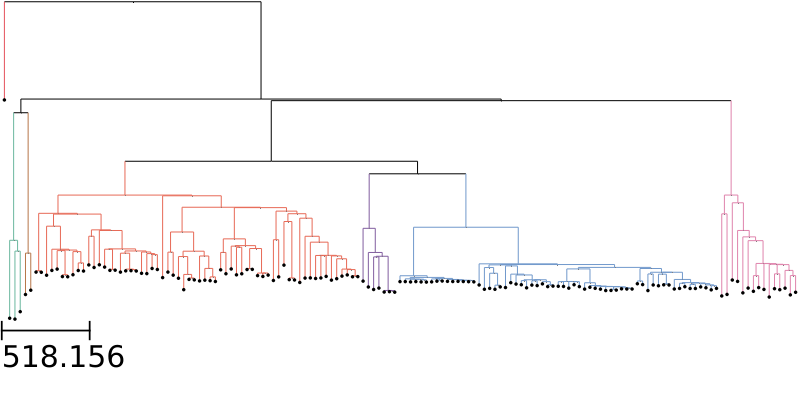

In [146]:
i_Gubbins_T.render("%%inline", w = 800, tree_style = ts_ColLin)

# Evaluate phylogenetic distribution of events and mutations of interest

## A) all ANTIGEN altering **putative** gene conversion events

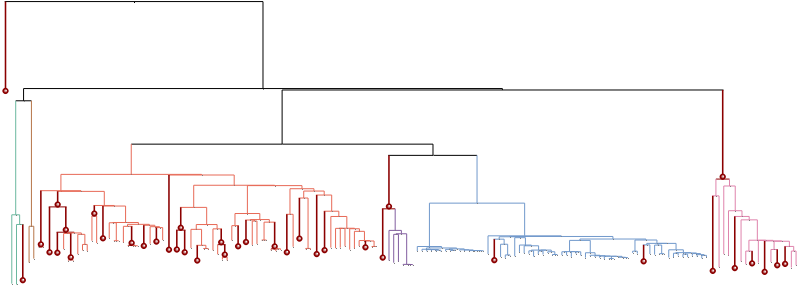

In [147]:
i_Target_Nodes = pGCE_WiNSMut_InAntigen_DF["Child_Node"].values

Tree_AllAntigenAltering_pGCEvents_Labeled_1 = highlight_TargetNodes_V2(i_Target_Nodes, i_Gubbins_T) 
Tree_AllAntigenAltering_pGCEvents_Labeled_1.render("%%inline", w = 800, tree_style = ts_4_NoScale)

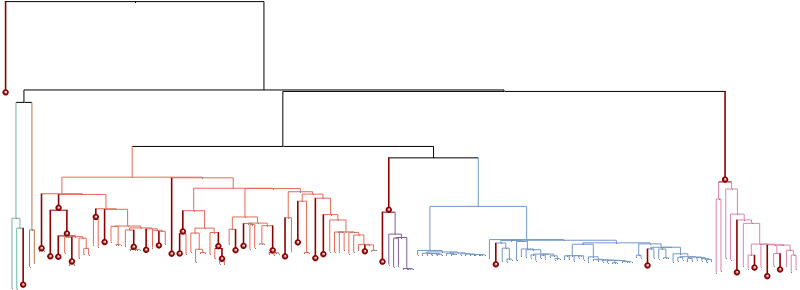

In [148]:
i_Target_Nodes = mGCE_WiNSMut_InAntigen_DF["Child_Node"].values

Tree_AllAntigenAltering_pGCEvents_Labeled_1 = highlight_TargetNodes_V2(i_Target_Nodes, i_Gubbins_T) 
Tree_AllAntigenAltering_pGCEvents_Labeled_1.render("%%inline", w = 800, tree_style = ts_4_NoScale)

## B) all `PPE18-PPE19-PPE60` altering gene conversion events

In [149]:
pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].value_counts().head(5)

Overlap_Genes
PPE60    8
PPE18    7
PPE19    5
esxL     5
esxP     3
Name: count, dtype: int64

####  `PPE18-PPE19-PPE60` altering gene conversion events TOGETHER

Any PPE18, PPE19, or PPE60 event


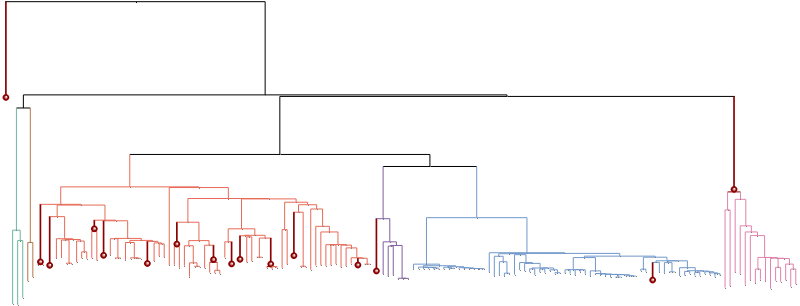

In [150]:
i_Target_Nodes = pGCE_WiNSMut_InAntigen_DF[pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].str.contains("PPE18") | 
                                           pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].str.contains("PPE18") |
                                           pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].str.contains("PPE60") ]["Child_Node"].values 

print("Any PPE18, PPE19, or PPE60 event")
Tree_PPE18_19_60_pGCEvents_Labeled_1 = highlight_TargetNodes_V2(i_Target_Nodes, i_Gubbins_T) 
Tree_PPE18_19_60_pGCEvents_Labeled_1.render("%%inline", w = 800, tree_style = ts_4_NoScale)


#### Only `PPE18` altering gene conversion events

Any PPE18 event


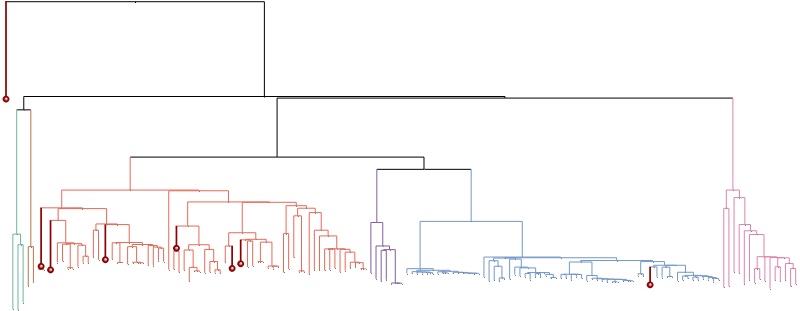

In [151]:
i_Target_Nodes = pGCE_WiNSMut_InAntigen_DF[pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].str.contains("PPE18")]["Child_Node"].values 

print("Any PPE18 event")

Tree_PPE18_pGCEvents_Labeled_1 = highlight_TargetNodes_V2(i_Target_Nodes, i_Gubbins_T) 
Tree_PPE18_pGCEvents_Labeled_1.render("%%inline", w = 800, tree_style = ts_4_NoScale)


In [152]:
pGCE_WiNSMut_InAntigen_DF[pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].str.contains("PPE18")]

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
90,NC_000962.3,1339399,1339436,0.0,.,Node_36,Node_28,655.459143,4,"['M0016395_7', 'R15311']",1339398,1339417.0,38,lineage4,PPE18,Rv1196,False,True,False,False,Event_091,2,1,0,0,PR_HmRegion_053,0,0,1,1,2,False,0.75,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.5769,NaN,26,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.75,1856181.5,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
91,NC_000962.3,1339432,1339516,0.0,.,Node_114,TB3368,475.291405,6,['TB3368'],1339431,1339473.5,85,lineage2,PPE18,Rv1196,False,True,False,False,Event_092,2,1,0,0,PR_HmRegion_053,0,0,1,1,1,True,1.00,2,1,PPE19-H37Rv-1532539-1533632,PPE19,1.0000,193612.0,31,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.50,1856238.0,True,3,2,4,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
92,NC_000962.3,1339432,1339774,0.0,.,Node_27,Node_5,1536.817046,5,"['mada_2-31', 'mada_1-41']",1339431,1339602.5,343,lineage4,PPE18,Rv1196,False,True,False,False,Event_093,2,1,0,0,PR_HmRegion_053,0,0,1,1,2,False,1.00,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.7027,NaN,37,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.80,1856367.0,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
93,NC_000962.3,1339648,1339806,0.0,.,Node_25,M0017522_5,1625.533450,20,['M0017522_5'],1339647,1339726.5,159,lineage4,PPE18,Rv1196,False,True,False,False,Event_094,2,1,0,0,PR_HmRegion_053,0,0,1,1,1,True,1.00,2,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.0000,1856491.0,114,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.00,1856491.0,True,17,8,6,"UnqPeptide_1812-PPE18,UnqPeptide_5494-PPE18,Un..."
94,NC_000962.3,1339861,1339905,0.0,.,Node_43,TB3237,688.268204,12,['TB3237'],1339860,1339882.5,45,lineage4,PPE18,Rv1196,False,True,False,False,Event_095,2,1,0,0,PR_HmRegion_053,0,0,1,1,1,True,1.00,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",1.0000,NaN,55,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.00,1856647.0,True,8,4,3,"UnqPeptide_998-PPE18,UnqPeptide_8744-PPE18,Unq..."
95,NC_000962.3,1339894,1340208,0.0,.,Node_17,TB3334,993.431569,8,['TB3334'],1339893,1340050.5,315,lineage4,PPE18,Rv1196,False,True,False,False,Event_096,2,1,0,0,PR_HmRegion_053,0,0,3,1,1,True,1.00,2,1,PPE19-H37Rv-1532539-1533632,PPE19,0.9688,193035.0,64,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.50,1856815.0,True,7,3,12,"UnqPeptide_959-PPE18,UnqPeptide_998-PPE18,UnqP..."
96,NC_000962.3,1339966,1340036,0.0,.,Node_37,01_R1430,622.305357,11,['01_R1430'],1339965,1340000.5,71,lineage4,PPE18,Rv1196,False,True,False,False,Event_097,2,1,0,0,PR_HmRegion_053,0,0,2,1,1,True,1.00,2,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.0000,1856765.0,57,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.00,1856765.0,True,8,1,6,UnqPeptide_15452-PPE18
97,NC_000962.3,1340500,1341152,0.0,.,Node_149,RW-TB008,4520.801917,10,['RW-TB008'],1340499,1340825.5,653,lineage8,"PPE18,esxK,esxL","Rv1196,Rv1197,Rv1198",True,True,False,False,Event_098,4,1,0,0,PR_HmRegion_054,0,0,1,1,1,True,0.60,4,1,"esxI,esxJ-H37Rv-1160545-1161167","esxI,esxJ",0.1573,179969.5,89,1,"esxM,esxN-H37Rv-2030331-2030976

#### Only `PPE19` altering gene conversion events

Any PPE19 event


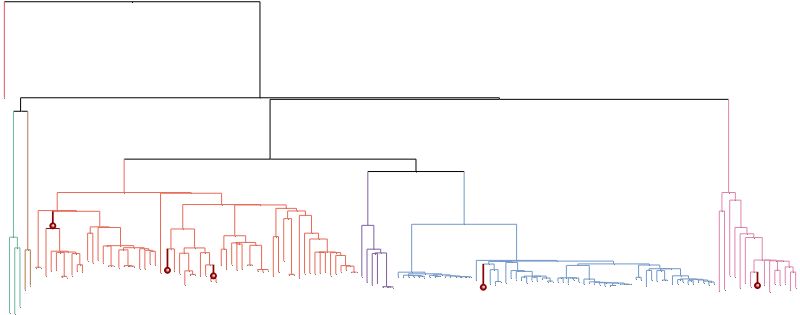

In [153]:
i_Target_Nodes = pGCE_WiNSMut_InAntigen_DF[pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].str.contains("PPE19")]["Child_Node"].values 
print("Any PPE19 event")
Tree_PPE19_pGCEvents_Labeled_1 = highlight_TargetNodes_V2(i_Target_Nodes, i_Gubbins_T) 
Tree_PPE19_pGCEvents_Labeled_1.render("%%inline", w = 800, tree_style = ts_4_NoScale)


In [154]:
pGCE_WiNSMut_InAntigen_DF[pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].str.contains("PPE19")]

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
109,NC_000962.3,1532656,1532855,0.0,.,Node_28,R15311,568.864078,5,['R15311'],1532655,1532755.0,200,lineage4,PPE19,Rv1361c,False,True,False,False,Event_110,2,1,0,0,PR_HmRegion_060,0,0,1,1,1,True,1.0,2,1,PPE60-H37Rv-3894405-3895588,PPE60,0.8108,2049290.5,37,1,PPE60-H37Rv-3894405-3895588,PPE60,0.20,2049290.5,True,4,0,4,.
110,NC_000962.3,1532656,1532889,0.0,.,Node_97,R37765,661.439122,12,['R37765'],1532655,1532772.0,234,lineage2,PPE19,Rv1361c,False,True,False,False,Event_111,2,1,0,0,PR_HmRegion_060,0,0,1,1,1,True,1.0,2,1,PPE60-H37Rv-3894405-3895588,PPE60,1.0000,2049307.5,62,1,PPE60-H37Rv-3894405-3895588,PPE60,0.25,2049307.5,True,11,0,5,.
111,NC_000962.3,1532911,1533016,0.0,.,Node_135,mada_1-36,450.466003,20,['mada_1-36'],1532910,1532963.0,106,lineage1,PPE19,Rv1361c,False,True,False,False,Event_112,2,1,0,0,PR_HmRegion_060,0,0,2,1,1,True,1.0,2,1,PPE18-H37Rv-1339349-1340433,PPE18,0.7600,193072.0,100,1,PPE18-H37Rv-1339349-1340433,PPE18,0.30,193072.0,True,16,0,1,.
112,NC_000962.3,1533159,1533241,0.0,.,Node_26,Node_25,379.338694,5,"['M0017522_5', 'S0106-01', 'R21770', 'R21839',...",1533158,1533199.5,83,lineage4,PPE19,Rv1361c,False,True,False,False,Event_113,2,1,0,0,PR_HmRegion_060,0,0,1,1,8,False,0.8,2,1,PPE18-H37Rv-1339349-1340433,PPE18,1.0000,193308.5,32,2,PPE18-H37Rv-1339349-1340433-PPE60-H37Rv-389440...,PPE18-PPE60,0.40,NaN,True,2,0,0,.
113,NC_000962.3,1533327,1533434,0.0,.,Node_30,Node_29,276.408286,4,"['TB2661', 'TB3386']",1533326,1533380.0,108,lineage4,PPE19,Rv1361c,False,True,False,False,Event_114,2,1,0,0,PR_HmRegion_060,0,0,1,1,2,False,1.0,2,1,PPE60-H37Rv-3894405-3895588,PPE60,1.0000,2049915.5,40,1,PPE60-H37Rv-3894405-3895588,PPE60,0.25,2049915.5,True,3,5,5,"UnqPeptide_4240-PPE19,UnqPeptide_5681-PPE19,Un..."


#### Only `PPE60` altering gene conversion events

Any PPE60 event


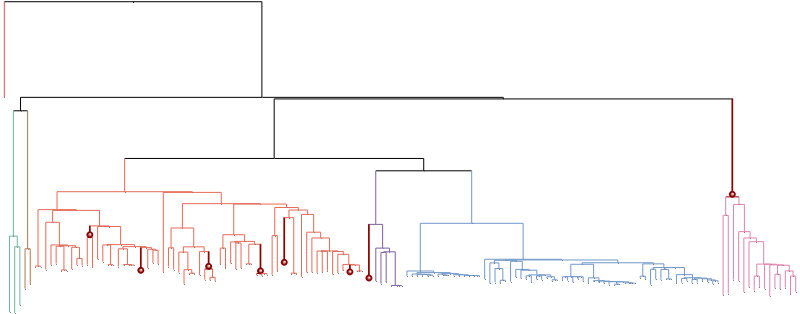

In [155]:
i_Target_Nodes = pGCE_WiNSMut_InAntigen_DF[pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].str.contains("PPE60")]["Child_Node"].values 
print("Any PPE60 event")
Tree_PPE60_pGCEvents_Labeled_1 = highlight_TargetNodes_V2(i_Target_Nodes, i_Gubbins_T) 
Tree_PPE60_pGCEvents_Labeled_1.render("%%inline", w = 800, tree_style = ts_4_NoScale)


In [156]:
pGCE_WiNSMut_InAntigen_DF[pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].str.contains("PPE60")]

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
289,NC_000962.3,3894588,3895342,0.0,.,Node_48,TB3054,1246.216765,27,['TB3054'],3894587,3894964.5,755,lineage4,PPE60,Rv3478,False,True,False,False,Event_290,2,1,0,0,PR_HmRegion_182,0,0,4,1,1,True,0.888889,2,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.8882,1856245.5,161,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.7778,1856245.5,True,23,1,5,UnqPeptide_7795-PPE60
290,NC_000962.3,3895055,3895116,0.0,.,Node_41,Node_39,711.840017,20,"['mada_103', 'mada_112', 'mada_124']",3895054,3895085.0,62,lineage4,PPE60,Rv3478,False,True,False,False,Event_291,2,1,0,0,PR_HmRegion_182,0,0,2,1,3,False,1.000000,2,1,PPE19-H37Rv-1532461-1533653,PPE19,0.7042,2049504.0,71,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.2000,1856125.0,True,15,1,0,UnqPeptide_7795-PPE60
291,NC_000962.3,3895055,3895116,0.0,.,Node_50,mada_1-50,235.832795,20,['mada_1-50'],3895054,3895085.0,62,lineage4,PPE60,Rv3478,False,True,False,False,Event_292,2,1,0,0,PR_HmRegion_182,0,0,2,1,1,True,1.000000,2,1,PPE19-H37Rv-1532461-1533653,PPE19,0.7042,2049504.0,71,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.2000,1856125.0,True,15,1,0,UnqPeptide_7795-PPE60
292,NC_000962.3,3895055,3895185,0.0,.,Node_9,mada_105,631.945972,33,['mada_105'],3895054,3895119.5,131,lineage4,PPE60,Rv3478,False,True,False,False,Event_293,2,1,0,0,PR_HmRegion_182,0,0,3,1,1,True,0.878788,2,1,PPE19-H37Rv-1532461-1533653,PPE19,0.8190,2049469.5,116,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.3636,1856090.5,True,28,1,0,UnqPeptide_7795-PPE60
293,NC_000962.3,3895067,3895082,0.0,.,Node_18,Node_6,223.573447,7,"['MT_0080', 'mada_102']",3895066,3895074.0,16,lineage4,PPE60,Rv3478,False,True,False,False,Event_294,2,1,0,0,PR_HmRegion_182,0,0,1,1,2,False,1.000000,2,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",1.0000,1856136.0,26,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",1.0000,1856136.0,True,6,0,0,.
294,NC_000962.3,3895067,3895257,0.0,.,Node_31,Node_30,412.863731,25,"['TB3162', 'TB2661', 'TB3386']",3895066,3895161.5,191,lineage4,PPE60,Rv3478,False,True,False,False,Event_295,2,1,0,0,PR_HmRegion_182,0,0,3,1,3,False,0.880000,2,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.9565,1856048.5,115,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.8800,1856048.5,True,22,1,1,UnqPeptide_7795-PPE60
295,NC_000962.3,3895146,3895159,0.0,.,Node_71,N1274,1455.059142,7,['N1274'],3895145,3895152.0,14,lineage3,PPE60,Rv3478,False,True,False,False,Event_296,2,1,0,0,PR_HmRegion_182,0,0,0,0,1,True,0.428571,2,1,PPE19-H37Rv-1532461-1533653,PPE19,1.0000,2049437.0,24,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.4286,1856058.0,True,7,0,0,.
296,NC_000962.3,3895247,3895282,0.0,.,Node_148,Node_147,2481.971754,5,"['R27252', 'R23887', 'N0153', 'N0072', 'mada_1...",3895246,3895264.0,36,lineage1,PPE60,Rv3478,False,True,False,False,Event_297,2,1,0,0,PR_HmRegion_182,0,0,1,1,15,False,1.000000,2,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.6364,1855946.0,44,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.8000,1855946.0,True,4,0,1,.


#### Only `PPE60` altering gene conversion events

Any PPE60 event


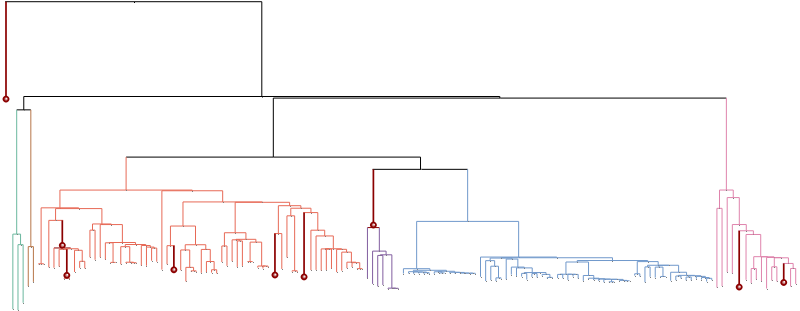

In [157]:
i_Target_Nodes = pGCE_WiNSMut_InAntigen_DF[pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].str.contains("esxL")]["Child_Node"].values 
print("Any PPE60 event")
Tree_esxL_pGCEvents_Labeled_1 = highlight_TargetNodes_V2(i_Target_Nodes, i_Gubbins_T) 
Tree_esxL_pGCEvents_Labeled_1.render("%%inline", w = 800, tree_style = ts_4_NoScale)


In [158]:
pGCE_WiNSMut_InAntigen_DF[pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].str.contains("esxL")]

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
97,NC_000962.3,1340500,1341152,0.0,.,Node_149,RW-TB008,4520.801917,10,['RW-TB008'],1340499,1340825.5,653,lineage8,"PPE18,esxK,esxL","Rv1196,Rv1197,Rv1198",True,True,False,False,Event_098,4,1,0,0,PR_HmRegion_054,0,0,1,1,1,True,0.600000,4,1,"esxI,esxJ-H37Rv-1160545-1161167","esxI,esxJ",0.1573,179969.5,89,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.3000,689828.0,True,3,1,4,UnqPeptide_4422-esxK
98,NC_000962.3,1340657,1341120,0.0,.,Node_59,01_R1134,1656.415569,5,['01_R1134'],1340656,1340888.0,464,lineage4,"esxK,esxL","Rv1197,Rv1198",True,False,False,False,Event_099,4,1,0,0,PR_HmRegion_054,0,0,1,1,1,True,1.000000,4,1,"esxV,esxW-H37Rv-4059985-4060591","esxV,esxW",0.6000,1692132.0,55,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.6000,689765.5,True,2,1,4,UnqPeptide_11315-esxL
99,NC_000962.3,1340667,1341102,0.0,.,Node_28,M0016395_7,650.777286,4,['M0016395_7'],1340666,1340884.0,436,lineage4,"esxK,esxL","Rv1197,Rv1198",True,False,False,False,Event_100,4,1,0,0,PR_HmRegion_054,0,0,1,1,1,True,0.500000,4,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.5000,689769.5,44,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.2500,689769.5,True,2,3,0,"UnqPeptide_11315-esxL,UnqPeptide_12306-esxL,Un..."
101,NC_000962.3,1340916,1341073,0.0,.,Node_46,M0016737_0,1168.490206,6,['M0016737_0'],1340915,1340994.0,158,lineage4,"esxK,esxL","Rv1197,Rv1198",True,False,False,False,Event_102,4,1,0,0,PR_HmRegion_054,0,0,1,1,1,True,0.833333,4,2,"esxI,esxJ-H37Rv-1160545-1161167-esxV,esxW-H37R...","esxI,esxJ-esxV,esxW",0.5312,NaN,64,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.6667,689659.5,True,1,1,0,UnqPeptide_16863-esxL
102,NC_000962.3,1340974,1341174,0.0,.,Node_137,mada_107,535.665848,15,['mada_107'],1340973,1341073.5,201,lineage1,esxL,Rv1198,True,False,False,False,Event_103,4,1,0,0,PR_HmRegion_054,0,0,1,1,1,True,0.666667,4,1,"esxO,esxP,Rv2348c-H37Rv-2625885-2626683","esxO,esxP,Rv2348c",0.4957,1285210.5,115,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.4667,689580.0,True,5,1,6,UnqPeptide_16863-esxL
104,NC_000962.3,1341023,1341295,0.0,.,Node_132,Node_71,1445.396970,5,"['N1274', 'N0054', 'QC-3', 'QC-9', 'QC-5', 'N0...",1341022,1341158.5,273,lineage3,esxL,Rv1198,True,False,False,False,Event_105,4,1,0,0,PR_HmRegion_054,0,0,1,1,7,False,0.800000,4,1,"esxO,esxP,Rv2348c-H37Rv-2625885-2626683","esxO,esxP,Rv2348c",0.6800,1285125.5,50,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.8000,689495.0,True,3,1,3,UnqPeptide_11315-esxL
105,NC_000962.3,1341029,1341120,0.0,.,Node_25,Node_24,677.651945,6,"['S0106-01', 'R21770', 'R21839', 'R21363', 'ma...",1341028,1341074.0,92,lineage4,esxL,Rv1198,True,False,False,False,Event_106,4,1,0,0,PR_HmRegion_054,0,0,1,1,7,False,1.000000,4,1,"esxO,esxP,Rv2348c-H37Rv-2625885-2626683","esxO,esxP,Rv2348c",0.9180,1285210.0,61,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.8333,689579.5,True,3,1,3,UnqPeptide_11315-esxL
106,NC_000962.3,1341032,1341254,0.0,.,Node_144,mada_1-10,1480.500925,4,['mada_1-10'],1341031,1341142.5,223,lineage1,esxL,Rv1198,True,False,False,False,Event_107,4,1,0,0,PR_HmRegion_054,0,0,1,1,1,True,1.000000,4,2,"esxI,esxJ-H37Rv-1160545-1161167-esxV,esxW-H37R...","esxI,esxJ